# CSI4142 Assignment 2
Jonathan Cojita, Lucas Gavura

## Part 2: Imputation
Jonathan Cojita

In [ ]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [31]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "yashdev01/spotify-tracks-dataset"
)

df = pd.read_csv(f"{path}/spotify-tracks-dataset.csv")
print(df.head())

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

### 2.1:
**Type of Imputation**: Default Imputation

**Description of Imputation**: Used Mean default imputation by taking average of non-null data in the attribute and imputing over null rows

**Type of Missing Data Simulated**: MCAR

**Attrtibute Affected**: Speechiness (how much spoken content is in the song)

**How Missing Data is Simulated**: We take a defined percentage of the dataset and at random, set that number of rows to have a null speechiness


speechiness - MCAR (Median)
Genre - MAR (Similarity Based)
Popularity - MCAR (Regression)


In [32]:
#Simulate MCAR over genre column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'speechiness'].copy()

df.loc[missing_indices, 'speechiness'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['speechiness'].isna()].head()[['track_name', 'artists', 'speechiness']])

               track_name                               artists  speechiness
1        Ghost - Acoustic                          Ben Woodward          NaN
16  ily (i love you baby)                  Andrew Foy;Renee Foy          NaN
22          Say Something  A Great Big World;Christina Aguilera          NaN
23       93 Million Miles                            Jason Mraz          NaN
29      Winter Wonderland                            Jason Mraz          NaN


In [33]:
#Calculate mean speechiness for imputation
mean_speechiness = df['speechiness'].mean()
print(f"Mean speechiness for imputation: {mean_speechiness}")

Mean speechiness for imputation: 0.08463575048732944


In [34]:
#Impute missing values with mode
imputed_indices = df[df['speechiness'].isna()].index
df['speechiness'] = df['speechiness'].fillna(mean_speechiness)

#Print the rows that were just imputed to confirm
print(f"Imputed {len(imputed_indices)} rows")
print(df.loc[imputed_indices, ['track_name', 'artists', 'speechiness']].head())

Imputed 11400 rows
               track_name                               artists  speechiness
1        Ghost - Acoustic                          Ben Woodward     0.084636
16  ily (i love you baby)                  Andrew Foy;Renee Foy     0.084636
22          Say Something  A Great Big World;Christina Aguilera     0.084636
23       93 Million Miles                            Jason Mraz     0.084636
29      Winter Wonderland                            Jason Mraz     0.084636


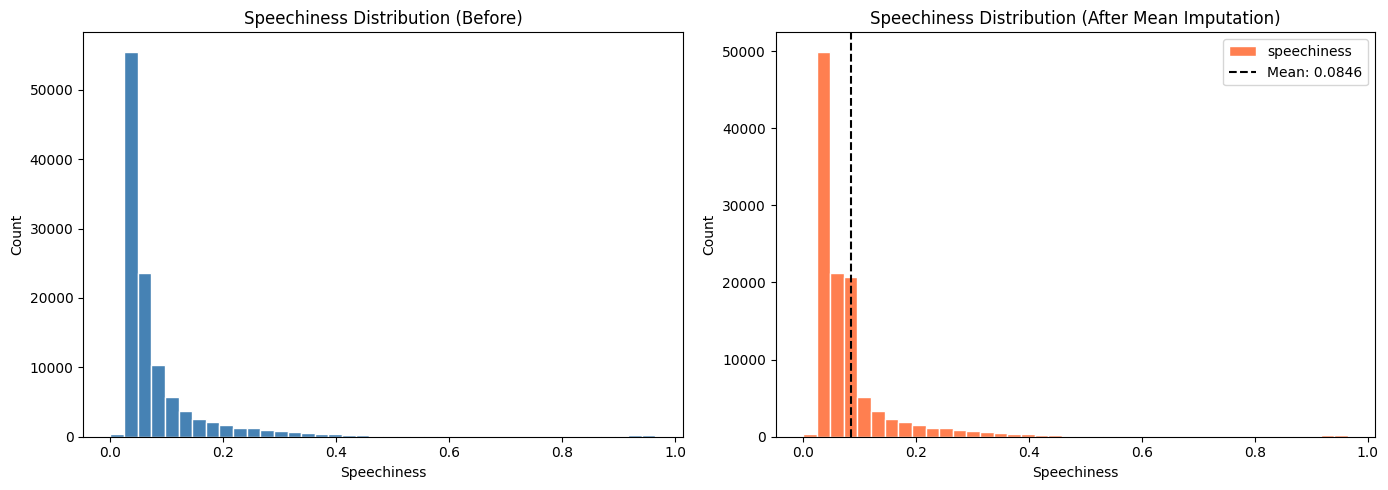

            Before     After     Delta
Mean      0.084652  0.084636 -0.000016
Median    0.048900  0.053300  0.004400
Std Dev   0.105732  0.099950 -0.005782
Skewness  4.647516  4.879235  0.231719


In [ ]:
#Quantitative evaluation

#Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'speechiness']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Speechiness Distribution (Before)')
axes[0].set_xlabel('Speechiness')
axes[0].set_ylabel('Count')

df['speechiness'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(mean_speechiness, color='black', linestyle='--', label=f'Mean: {mean_speechiness:.4f}')
axes[1].set_title('Speechiness Distribution (After Mean Imputation)')
axes[1].set_xlabel('Speechiness')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

#Compare distribution statistics before and after imputation
stats = pd.DataFrame({
    'Before': [
        before_full.mean(),
        before_full.median(),
        before_full.std(),
        before_full.skew(),
    ],
    'After': [
        df['speechiness'].mean(),
        df['speechiness'].median(),
        df['speechiness'].std(),
        df['speechiness'].skew(),
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Skewness'])

stats['Delta'] = stats['After'] - stats['Before']
print(stats.round(6))

**Analysis**: Observing the before and after distribution, it is aparent the change that our imputations made, however largley the distrtibution of the data overall seems similar. Looking at the distribution values we also see very slight changes between the values.

## 2.2

**Type of Imputation**:

**Description of Imputation**:

**Type of Missing Data Simulated**: MAR
**Attribute Affected**: track_genre
**How Missing Data is Simulated**: Songs with lower popularity are assigned a higher probability of having a missing genre, creating a dependency between missingness and an observed variable (popularity).

In [ ]:
# Simulate MAR over track_genre column
# Songs with lower popularity have a higher probability of missing genre
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)

# Weight is inversely proportional to popularity: low popularity -> high missingness probability
weights = (df['popularity'].max() - df['popularity'] + 1).astype(float)
prob = weights / weights.sum()

missing_indices_genre = np.random.choice(df.index, size=n_missing, replace=False, p=prob)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values_mar = df.loc[missing_indices_genre, 'track_genre'].copy()

df.loc[missing_indices_genre, 'track_genre'] = np.nan

# Verify MAR mechanism: missing rows should have a lower mean popularity than the full dataset
print(f"Mean popularity (all rows):           {df['popularity'].mean():.2f}")
print(f"Mean popularity (missing genre rows): {df.loc[missing_indices_genre, 'popularity'].mean():.2f}")
print()
print(df[df['track_genre'].isna()].head()[['track_name', 'artists', 'popularity', 'track_genre']])

## 2.3

**Type of Imputation**: Regression Imputation

**Description of Imputation**: Trained a RandomForrestRegressor using Scikit-learn to predict populatirity (attribute with missing data) using all other attributes as features.

**Type of Missing Data Simulated**: MCAR

**Attrtibute Affected**: Popularity (A continious variable from 0 - 100 representing how popular the song is).

**How Missing Data is Simulated**: We take a defined percentage of the dataset and at random, set that number of rows to have a null popularity.


In [36]:
#Simulate MCAR over popularity column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'popularity'].copy()

df.loc[missing_indices, 'popularity'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['popularity'].isna()].head()[['track_name', 'artists', 'popularity']])

                track_name                artists  popularity
7                I'm Yours             Jason Mraz         NaN
13                Bad Liar          Anna Hamilton         NaN
25              Bella Luna             Jason Mraz         NaN
30       Winter Wonderland             Jason Mraz         NaN
43  You and Me on the Rock  Brandi Carlile;Lucius         NaN


In [ ]:
#Train a regression model to predict missing popularity

feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'explicit', 'mode', 'time_signature'
]

#Split df into rows where popularity is known vs missing
df_known = df[df['popularity'].notna()]
df_missing = df[df['popularity'].isna()]

#Split known rows into train/test to evaluate model performance
X = df_known[feature_cols]
y = df_known['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train model on training portion of known rows
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

Test MAE:  11.2186
Test RMSE: 15.5217


In [ ]:
#Predict popularity for missing rows usingthe trained model
X_pred = df_missing[feature_cols]
predicted = model.predict(X_pred)

#Impute predictions
df.loc[df['popularity'].isna(), 'popularity'] = predicted

print(f"Imputed {len(df_missing)} rows")
print(df.loc[df_missing.index[:5], ['track_name', 'artists', 'popularity']])

Imputed 11400 rows
                track_name                artists  popularity
7                I'm Yours             Jason Mraz   71.985000
13                Bad Liar          Anna Hamilton   55.567500
25              Bella Luna             Jason Mraz   23.409091
30       Winter Wonderland             Jason Mraz    0.000000
43  You and Me on the Rock  Brandi Carlile;Lucius    7.654545


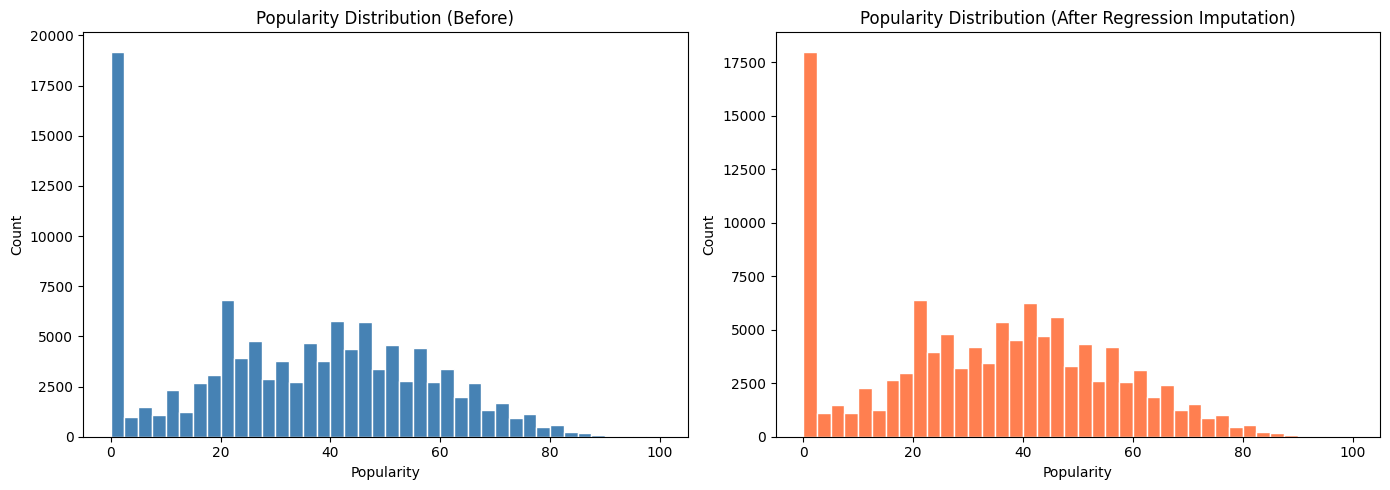

             Before      After     Delta
Mean      33.238535  33.193897 -0.044638
Median    35.000000  35.000000  0.000000
Std Dev   22.305078  21.668420 -0.636659
Skewness   0.046403   0.034838 -0.011564
Test MAE:  11.2186
Test RMSE: 15.5217


In [ ]:
#Quantitative evaluation
#Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'popularity']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Distribution (Before)')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')

df['popularity'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Popularity Distribution (After Regression Imputation)')
axes[1].set_xlabel('Popularity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#Compare distribution values before and after imputation
stats = pd.DataFrame({
    'Before': [
        before_full.mean(),
        before_full.median(),
        before_full.std(),
        before_full.skew(),
    ],
    'After': [
        df['popularity'].mean(),
        df['popularity'].median(),
        df['popularity'].std(),
        df['popularity'].skew(),
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Skewness'])

stats['Delta'] = stats['After'] - stats['Before']
print(stats.round(6))

#Model performance evalutaion
y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# References
- https://seaborn.pydata.org/
- https://github.com/lemay-ai/CEG4195-SEG4180/tree/main 
    - (Course Github for SEG4180 used for model training reference)
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html